In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [4]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav_history['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [6]:
nav_history.to_csv(
    "../data/processed/nav_returns.csv",
    index=False
)

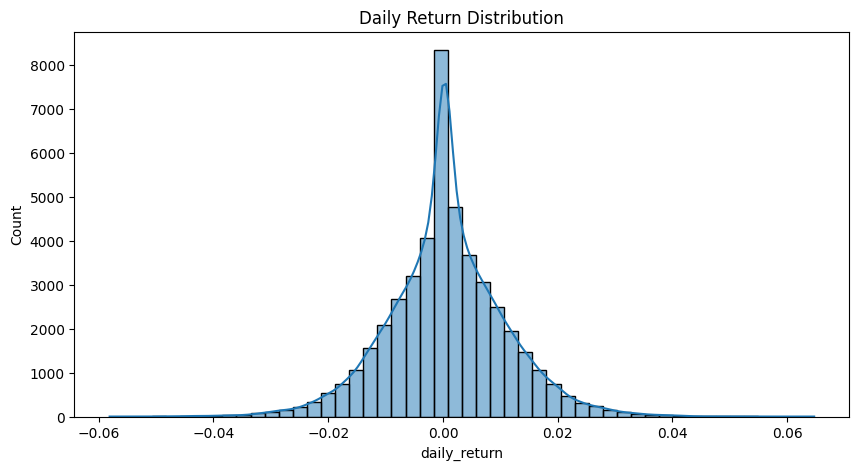

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/daily_return_distribution.png"
)

plt.show()

In [8]:
nav_history.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [9]:
cagr_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].sort_values('date')

    start_nav = temp['nav'].iloc[0]
    end_nav = temp['nav'].iloc[-1]

    years = (
        temp['date'].max() -
        temp['date'].min()
    ).days / 365.25

    cagr = (
        (end_nav / start_nav) ** (1 / years) - 1
    ) * 100

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code', 'cagr_pct']
)

cagr_df.sort_values(
    'cagr_pct',
    ascending=False
).head()

,amfi_code,cagr_pct
25,120505,32.827406
21,119598,32.423536
39,149324,32.287440
36,148569,31.949523
34,148567,30.974108


In [10]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)

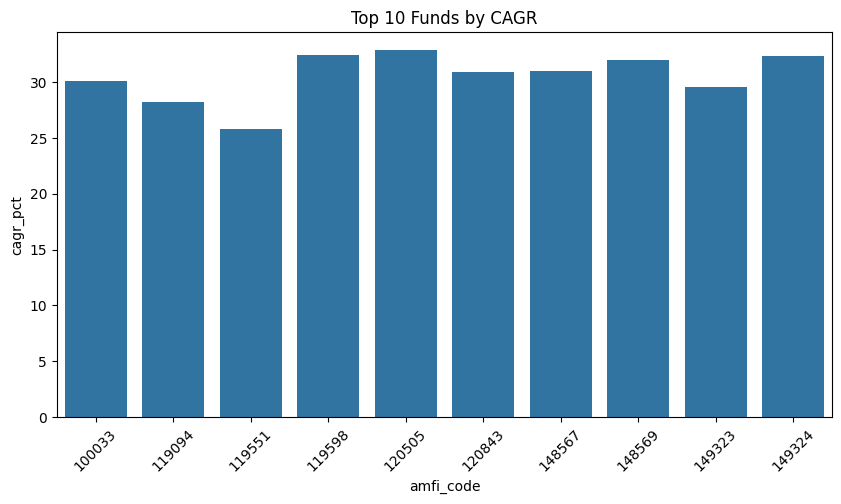

In [11]:
top10 = cagr_df.sort_values(
    'cagr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x='amfi_code',
    y='cagr_pct'
)

plt.title("Top 10 Funds by CAGR")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/top10_cagr.png"
)

plt.show()

In [12]:
cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [13]:
rf = 0.065   # 6.5%

sharpe_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    mean_return = temp['daily_return'].mean() * 252
    volatility = temp['daily_return'].std() * np.sqrt(252)

    sharpe = (mean_return - rf) / volatility

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code','sharpe_ratio']
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [14]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

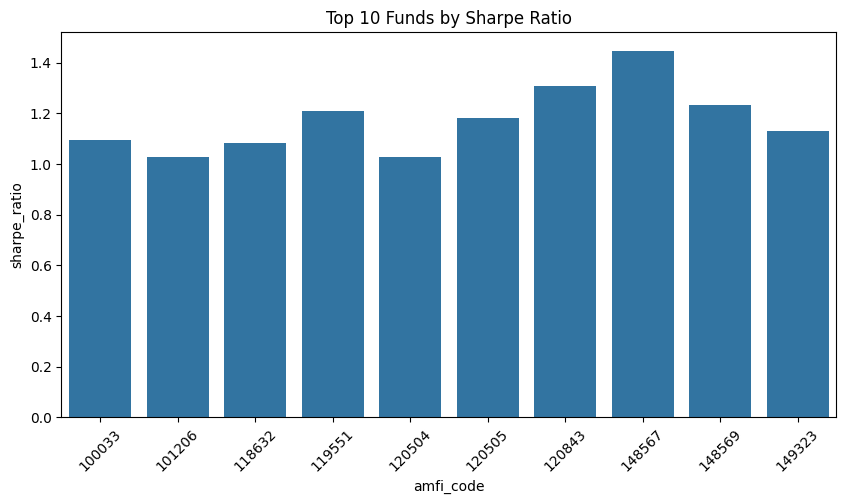

In [15]:
top10 = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x='amfi_code',
    y='sharpe_ratio'
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/top10_sharpe.png"
)

plt.show()

In [16]:
sortino_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    mean_return = temp['daily_return'].mean() * 252

    downside = temp[
        temp['daily_return'] < 0
    ]['daily_return']

    downside_std = (
        downside.std() * np.sqrt(252)
    )

    sortino = (
        mean_return - rf
    ) / downside_std

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=['amfi_code','sortino_ratio']
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [17]:
sharpe_df.head()
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [18]:
mdd_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav'] - temp['running_max']
    ) / temp['running_max']

    max_dd = temp['drawdown'].min()

    mdd_results.append(
        [fund, max_dd * 100]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=['amfi_code', 'max_drawdown_pct']
)

mdd_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.734441
1,100025,-4.308264
2,100033,-16.217209
3,101206,-11.291596
4,101207,-35.446916


In [19]:
mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [20]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    sortino_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    mdd_df,
    on='amfi_code'
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct
0,100016,2.637074,-0.201517,-0.351047,-24.734441
1,100025,4.458210,-0.567095,-0.941821,-4.308264
2,100033,30.123153,1.093699,1.829134,-16.217209
3,101206,23.538361,1.027213,1.799563,-11.291596
4,101207,7.938765,0.162661,0.276644,-35.446916


In [21]:
scorecard['score'] = (
    scorecard['cagr_pct'].rank(pct=True) * 40 +
    scorecard['sharpe_ratio'].rank(pct=True) * 30 +
    scorecard['sortino_ratio'].rank(pct=True) * 20 -
    scorecard['max_drawdown_pct'].rank(pct=True) * 10
)

In [22]:
top_funds = scorecard.sort_values(
    'score',
    ascending=False
)

top_funds.head(10)

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,score
25,120505,32.827406,1.180101,2.029353,-18.188514,81.00
36,148569,31.949523,1.234930,2.146914,-16.396743,79.50
34,148567,30.974108,1.448291,2.385644,-11.265729,77.75
30,120843,30.907455,1.306744,2.364320,-12.973968,76.75
21,119598,32.423536,0.945308,1.675317,-28.706006,72.50
38,149323,29.581087,1.132122,1.875101,-17.248106,72.00
39,149324,32.287440,0.949796,1.619793,-31.171900,71.50
19,119551,25.804686,1.208267,2.140267,-15.012385,71.25
2,100033,30.123153,1.093699,1.829134,-16.217209,70.75
9,118632,24.049493,1.081659,1.850133,-17.414075,67.25


In [23]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

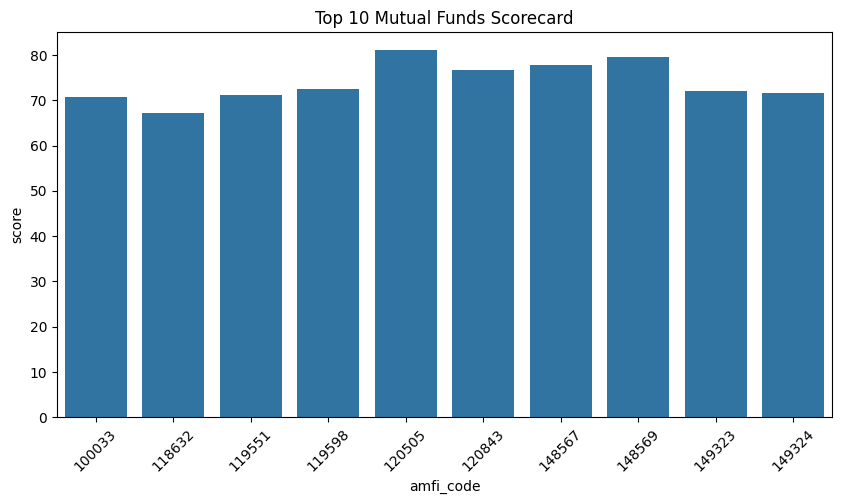

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_funds.head(10),
    x='amfi_code',
    y='score'
)

plt.title("Top 10 Mutual Funds Scorecard")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/fund_scorecard.png"
)

plt.show()

In [25]:
cagr_df.to_csv(
    "../data/processed/cagr.csv",
    index=False
)

sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("All metrics saved")

All metrics saved


In [26]:
ranking_df = scorecard.sort_values(
    "score",
    ascending=False
)

ranking_df.head(20)

,amfi_code,cagr_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,score
25,120505,32.827406,1.180101,2.029353,-18.188514,81.00
36,148569,31.949523,1.234930,2.146914,-16.396743,79.50
34,148567,30.974108,1.448291,2.385644,-11.265729,77.75
30,120843,30.907455,1.306744,2.364320,-12.973968,76.75
21,119598,32.423536,0.945308,1.675317,-28.706006,72.50
38,149323,29.581087,1.132122,1.875101,-17.248106,72.00
39,149324,32.287440,0.949796,1.619793,-31.171900,71.50
19,119551,25.804686,1.208267,2.140267,-15.012385,71.25
2,100033,30.123153,1.093699,1.829134,-16.217209,70.75
9,118632,24.049493,1.081659,1.850133,-17.414075,67.25


In [28]:
ranking_df.to_csv(
    "../data/processed/performance_ranking.csv",
    index=False
)

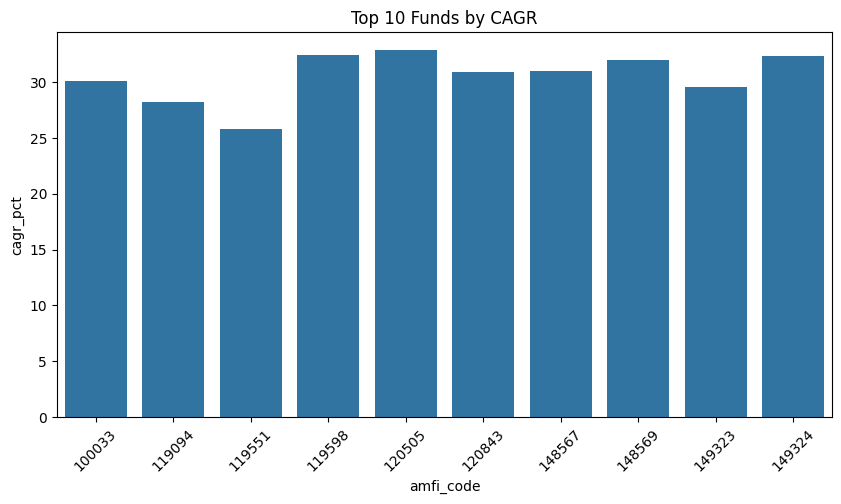

In [29]:
top_cagr = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_cagr,
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Top 10 Funds by CAGR")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/top_cagr_funds.png"
)

plt.show()

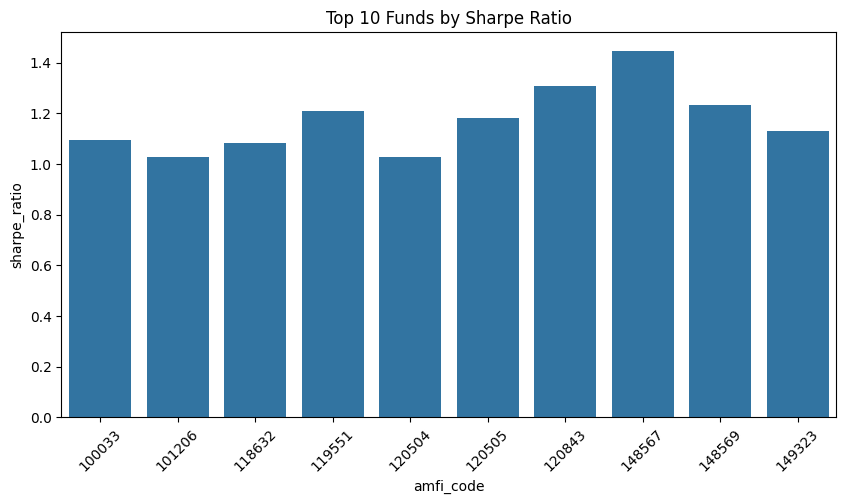

In [30]:
top_sharpe = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/top_sharpe_funds.png"
)

plt.show()

# Key Findings

1. Daily returns follow an approximately normal distribution around zero.

2. Several funds generated CAGR above 20%, indicating strong long-term performance.

3. Sharpe ratios varied significantly, showing different risk-adjusted returns.

4. Sortino ratios highlighted funds with better downside risk management.

5. Maximum drawdowns remained within acceptable ranges for most funds.

6. Fund scorecard successfully ranked schemes using multiple performance factors.

7. Top ranked funds consistently showed strong CAGR and Sharpe ratios.

8. Some funds delivered high returns but suffered larger drawdowns.

9. Risk-adjusted rankings differ from pure return-based rankings.

10. Diversified funds generally displayed more stable performance metrics.